# Credit Card Fraud Detection Using ML and DL

This notebook builds machine learning and deep learning models to detect fraudulent credit card transactions.

## 1. Importing Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

## 2. Setting Project Paths

In [2]:
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "data" / "creditcard.csv"
MODEL_DIR = PROJECT_DIR / "models"
RESULT_DIR = PROJECT_DIR / "results"

MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

## 3. Preparing Dataset

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Download the Kaggle credit card fraud CSV "
        "and save it as data/creditcard.csv"
    )

df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4. Dataset Overview

In [5]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass distribution:")
print(df["Class"].value_counts())

Dataset shape: (284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


## 5. Visualizing Class Imbalance

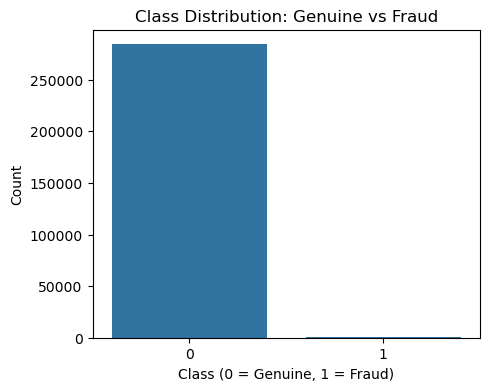

In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Class")
plt.title("Class Distribution: Genuine vs Fraud")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

## 6. Feature and Target Selection

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

feature_names = X.columns.tolist()
print("Total features:", len(feature_names))
print("Target column: Class")

Total features: 30
Target column: Class


## 7. Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


## 8. Feature Scaling

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


## 9. Handling Imbalanced Data With SMOTE

In [10]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

  File "C:\Users\Jothiprakash\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Jothiprakash\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Jothiprakash\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Jothipraka

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


## 10. Defining Evaluation Functions

In [11]:
def calculate_metrics(model_name, model_type, y_true, y_pred, y_probability):
    return {
        "model_name": model_name,
        "model_type": model_type,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc": average_precision_score(y_true, y_probability),
    }


def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 11. Training Machine Learning Models

Training Logistic Regression...
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



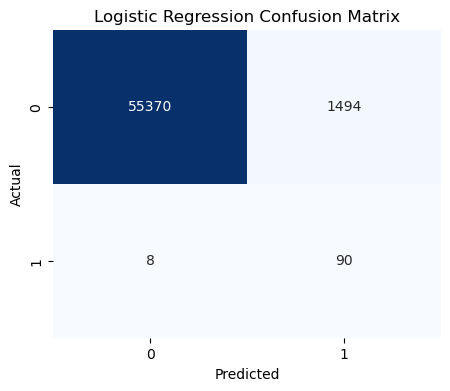

Training Random Forest...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.55      0.85      0.67        98

    accuracy                           1.00     56962
   macro avg       0.78      0.92      0.83     56962
weighted avg       1.00      1.00      1.00     56962



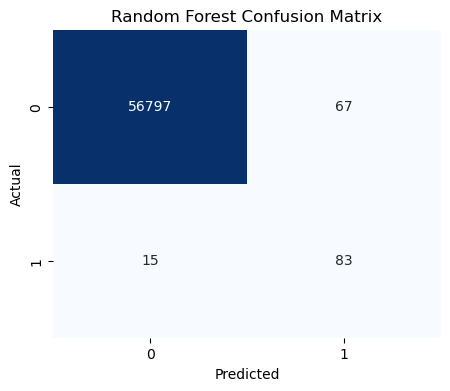

Training Gradient Boosting...


KeyboardInterrupt: 

In [12]:
ml_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        max_depth=12,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

trained_ml_models = {}
all_metrics = []

for model_name, model in ml_models.items():
    print(f"Training {model_name}...")
    model.fit(X_train_balanced, y_train_balanced)

    y_pred = model.predict(X_test_scaled)
    y_probability = model.predict_proba(X_test_scaled)[:, 1]

    trained_ml_models[model_name] = model
    all_metrics.append(calculate_metrics(model_name, "machine_learning", y_test, y_pred, y_probability))

    print(classification_report(y_test, y_pred, zero_division=0))
    plot_confusion_matrix(model_name, y_test, y_pred)

## 12. Building Deep Learning Model

In [ ]:
tf.random.set_seed(RANDOM_STATE)

dl_model = Sequential([
    Input(shape=(X_train_balanced.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(1, activation="sigmoid"),
])

dl_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

dl_model.summary()

## 13. Training Deep Learning Model

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history = dl_model.fit(
    X_train_balanced,
    y_train_balanced,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1,
)

## 14. Evaluating Deep Learning Model

In [ ]:
dl_probability = dl_model.predict(X_test_scaled).ravel()
dl_pred = (dl_probability >= 0.5).astype(int)

print(classification_report(y_test, dl_pred, zero_division=0))
plot_confusion_matrix("Deep Learning", y_test, dl_pred)

all_metrics.append(calculate_metrics("Deep Learning", "deep_learning", y_test, dl_pred, dl_probability))

## 15. Comparing All Models

In [ ]:
comparison_df = pd.DataFrame(all_metrics).sort_values(by="f1_score", ascending=False)
comparison_df

## 16. Saving Results

In [ ]:
comparison_path = RESULT_DIR / "model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"Model comparison saved to {comparison_path}")

## 17. Saving Best Model

In [ ]:
best_row = comparison_df.iloc[0]
best_model_name = best_row["model_name"]
best_model_type = best_row["model_type"]

print("Best model:", best_model_name)
print("Best model type:", best_model_type)

if best_model_type == "deep_learning":
    dl_model.save(MODEL_DIR / "best_deep_learning_model.keras")
else:
    best_model = trained_ml_models[best_model_name]
    joblib.dump(best_model, MODEL_DIR / "best_model.joblib")

metadata = {
    "best_model_name": best_model_name,
    "best_model_type": best_model_type,
    "feature_names": feature_names,
    "scaler": scaler,
    "metrics": comparison_df.to_dict(orient="records"),
}

joblib.dump(metadata, MODEL_DIR / "model_metadata.joblib")
print("Best model artifacts saved in the models folder.")

## 18. Testing Saved Model Artifacts

In [ ]:
saved_metadata = joblib.load(MODEL_DIR / "model_metadata.joblib")
sample_transaction = X_test.iloc[[0]]
sample_scaled = saved_metadata["scaler"].transform(sample_transaction[saved_metadata["feature_names"]])

if saved_metadata["best_model_type"] == "deep_learning":
    loaded_model = tf.keras.models.load_model(MODEL_DIR / "best_deep_learning_model.keras")
    fraud_probability = loaded_model.predict(sample_scaled).ravel()[0]
else:
    loaded_model = joblib.load(MODEL_DIR / "best_model.joblib")
    fraud_probability = loaded_model.predict_proba(sample_scaled)[:, 1][0]

prediction = "Fraud" if fraud_probability >= 0.5 else "Genuine"
print("Fraud probability:", fraud_probability)
print("Prediction:", prediction)

## 19. Streamlit Deployment

After running this notebook successfully, start the app with:

```bash
streamlit run app.py
```